# A11 — QFT and Phase Estimation From Scratch

**Track A — under the hood.** Pure NumPy. Qiskit is not imported anywhere in this
notebook; every matrix, every probability and every bound below is one you can
derive with a pen.

---

## The one-sentence version

The **quantum Fourier transform** is a change of basis that asks one question of
a state: *how fast is your phase winding as you walk along the basis states?*
**Phase estimation** is the trick that arranges for the answer to be a number you
were trying to compute, and then reads it off as bits.

## The plain-language on-ramp

Take an $n$-qubit register, $N = 2^n$ basis states, and think of the amplitude
vector as a list of $N$ complex numbers laid out left to right. Two different
things can be going on in that list:

- the **magnitudes** vary — some basis states are more likely than others;
- the **phases** vary — as you step from index $j$ to $j+1$, the little clock
  hand on top of the bar turns by some angle.

The second one is the interesting one. If the hand turns by a *constant* angle at
every step, the state is a **spiral**: a pure tone, with a well-defined winding
rate. The QFT takes that spiral in and gives you back a single spike, positioned
at the winding rate. Spiral in, spike out. That is the whole idea, and it is
exactly what a classical Fourier transform does — sine wave in, single frequency
bin out.

Run it backwards and it is just as useful: a **spike** in (one basis state, one
definite number $j$) comes out as a **perfect spiral** whose winding rate is $j$.
That direction is the one phase estimation exploits.

So here is the algorithm in four lines:

1. Put a counting register into a flat superposition of all $j$.
2. Use phase kickback (A06, A08) to stamp the phase $e^{2\pi i \varphi j}$ onto
   basis state $j$ — the register is now a spiral winding at rate $\varphi$.
3. Apply the **inverse** QFT. The spiral collapses onto the spike at $j
   \approx \varphi N$.
4. Measure. The bits you get are the binary expansion of $\varphi$.

Everything hard about this notebook is in the word "$\approx$". If $\varphi$
happens to be exactly $m/N$ for an integer $m$, step 3 is *perfect* — one
outcome, probability 1. If it isn't, the spiral doesn't fit a whole number of
turns into the register and the spike smears out into a skirt of
neighbours: **spectral leakage**, the same phenomenon that makes you window your
data before an FFT. We will measure that skirt, and prove the floor underneath
it: the nearest bitstring still wins with probability at least $4/\pi^2 \approx
0.405$, no matter how badly $\varphi$ misfits.

## What we build here

1. The QFT as an explicit $N \times N$ matrix, and **the phase swirl** — the
   picture of $\omega^{jk}$ that makes the whole transform legible at a glance.
2. What it does to a basis state, a uniform state and a periodic comb: period in,
   frequency out.
3. The **circuit** form — Hadamards, a controlled-phase ladder, and a final
   qubit-reversal layer — asserted equal to the matrix to $10^{-12}$. The
   reversal layer is where little-endian bugs hide, so we draw the matrix with it
   left out.
4. Phase estimation on an exactly representable phase (one sharp spike) and on an
   inexact one (leakage), with the analytic Dirichlet kernel laid over the
   simulated probabilities and the $4/\pi^2$ bound drawn in.
5. Precision versus counting-register size, and the honest limits: why this is
   *not* a fast DFT for your CSV file.

In [1]:
from qviz import backends, grid, style

import matplotlib.pyplot as plt
import numpy as np

style.use()

SEED = backends.seed_for("A11")
rng = np.random.default_rng(SEED)
print("seed:", SEED)

seed: 20260815


## The convention, pinned down before anything else

The QFT is *the* place bit-ordering bugs hide, because the circuit form ends with
a qubit-reversal layer whose necessity depends entirely on which end of the
bitstring you call qubit 0. So we state the convention, then assert it in code.

**Little-endian, matching the rest of the repo and matching Qiskit (A05, A06).**
Basis state index $j$ of an $n$-qubit register is the bitstring in which **qubit
0 is the rightmost character**:

$$j = \sum_{q=0}^{n-1} j_q\,2^q, \qquad j_q = \texttt{(j >> q) \& 1}.$$

To place a single-qubit operator on qubit $k$ the Kronecker factors run from the
*highest* qubit index down to 0 — `op_on` below is character-for-character the
helper A05 and A06 use.

**The transform itself.** With $\omega = e^{2\pi i/N}$ and $N = 2^n$,

$$F\,|j\rangle = \frac{1}{\sqrt N}\sum_{k=0}^{N-1}\omega^{jk}\,|k\rangle,
\qquad\text{i.e.}\qquad F_{kj} = \frac{\omega^{jk}}{\sqrt N}.$$

Note $F_{kj} = F_{jk}$: the QFT matrix is **symmetric** (not Hermitian —
symmetric). That is a small mercy, because it means the matrix itself carries no
row-vs-column ordering ambiguity. All the ordering pain lives in the *circuit*,
which is exactly where we will go looking for it.

In [2]:
I2 = np.eye(2, dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
P1 = np.array([[0, 0], [0, 1]], dtype=complex)      # |1><1|


def op_on(U, k, n):
    """Place the single-qubit operator U on qubit k of an n-qubit register.

    Little-endian: qubit 0 is the RIGHTMOST label character, so it is the LAST
    Kronecker factor. The loop runs n-1 down to 0.
    """
    out = np.array([[1.0 + 0j]])
    for j in range(n - 1, -1, -1):
        out = np.kron(out, U if j == k else I2)
    return out


def label(i, n):
    """The printed bitstring: qubit n-1 leftmost, qubit 0 rightmost."""
    return format(i, f"0{n}b")


def qft_matrix(n):
    """F_{kj} = exp(2 pi i j k / N) / sqrt(N), the QFT as a dense matrix."""
    N = 2 ** n
    j = np.arange(N)
    return np.exp(2j * np.pi * np.outer(j, j) / N) / np.sqrt(N)


F3 = qft_matrix(3)

print("F is unitary   :", np.allclose(F3.conj().T @ F3, np.eye(8)))
print("F is symmetric :", np.allclose(F3, F3.T))
print("F is Hermitian :", np.allclose(F3, F3.conj().T), " (no - and it need not be)")
print("every |entry|  :", np.round(np.unique(np.round(np.abs(F3), 12)), 6),
      f"  = 1/sqrt(8) = {1/np.sqrt(8):.6f}")
print("\nF^4 == I ?     :", np.allclose(np.linalg.matrix_power(F3, 4), np.eye(8)))
print("F^2 is the index-reversal permutation j -> (-j) mod N:")
F2 = np.linalg.matrix_power(F3, 2)
print("  ", [int(np.argmax(np.abs(F2[:, j]))) for j in range(8)],
      "  vs  ", [(-j) % 8 for j in range(8)])

F is unitary   : True
F is symmetric : True
F is Hermitian : False  (no - and it need not be)
every |entry|  : [0.353553]   = 1/sqrt(8) = 0.353553

F^4 == I ?     : True
F^2 is the index-reversal permutation j -> (-j) mod N:
   [0, 7, 6, 5, 4, 3, 2, 1]   vs   [0, 7, 6, 5, 4, 3, 2, 1]


Three facts worth carrying:

- **Every entry has the same magnitude**, $1/\sqrt N$. The QFT stores *nothing*
  in its magnitudes. All of the information is in the phases — which is why the
  next figure is a phase plot and why a real-part heatmap of this matrix would be
  actively misleading.
- **$F^4 = I$.** Fourier-transform four times and you are back where you started.
  Twice gets you the index-reversal permutation $j \mapsto -j \bmod N$, which is
  the discrete echo of "the Fourier transform of the Fourier transform of $f(x)$
  is $f(-x)$".
- $F$ is symmetric but not Hermitian, so $F^{-1} = F^\dagger = \bar F$ — the
  inverse QFT is just the complex conjugate, $\omega \to \omega^{-1}$.

## Figure 1 — the QFT matrix is a phase swirl

Here is the signature picture of this notebook.

Colour each cell of $F$ by the **phase** of that entry, on the repo's cyclic
phase map. Entry $(k, j)$ has phase $2\pi jk/N$, so:

- **row $k$ is a linear phase ramp in $j$ with slope $k$** — walking along row
  $k$ takes you around the colour wheel exactly $k$ times;
- column $j$ does the same thing by symmetry;
- row 0 and column 0 are constant (phase 0), the DC component.

Stack $N$ ramps of increasing slope on top of each other and you get the swirl:
a set of hyperbola-like fringes radiating from the top-left corner, aliasing into
a **moiré** pattern once $k$ approaches $N$ and the ramp turns faster than one
pixel per cycle. The moiré is not a rendering artefact — it is the honest picture
of the transform running out of resolution, which is the same finiteness that
causes leakage in the second half of this notebook.

The bottom-right panel unrolls four individual rows so you can see that the swirl
really is nothing but sawtooth ramps of different slopes.

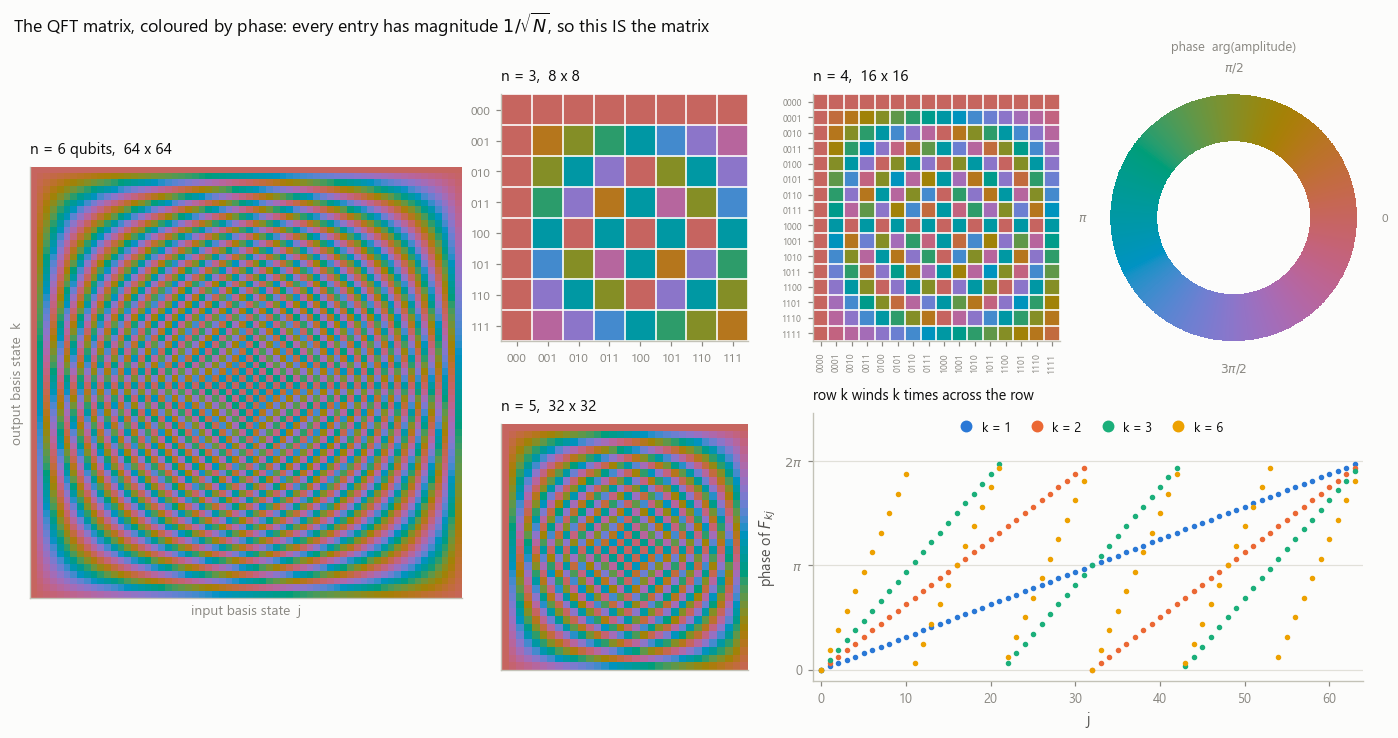

all |F_kj| equal? True


In [3]:
fig = plt.figure(figsize=(12.6, 6.6))
gs = fig.add_gridspec(2, 4, width_ratios=[1.75, 1, 1, 1.05])

ax_big = fig.add_subplot(gs[:, 0])
grid.matrix(ax_big, qft_matrix(6), part="phase", cbar=False, annot=False,
            title="n = 6 qubits,  64 x 64")
ax_big.set_xlabel("input basis state  j", fontsize=9, color=style.MUTED)
ax_big.set_ylabel("output basis state  k", fontsize=9, color=style.MUTED)

for slot, n in [(gs[0, 1], 3), (gs[0, 2], 4), (gs[1, 1], 5)]:
    ax = fig.add_subplot(slot)
    grid.matrix(ax, qft_matrix(n), part="phase", cbar=False, annot=False,
                title=f"n = {n},  {2**n} x {2**n}")

axw = fig.add_subplot(gs[0, 3], projection="polar")
style.phase_wheel(axw)

# The swirl, unrolled: row k of F is a sawtooth with exactly k teeth.
axr = fig.add_subplot(gs[1, 2:4])
N = 64
jj = np.arange(N)
for c, k in enumerate([1, 2, 3, 6]):
    axr.plot(jj, (2 * np.pi * jj * k / N) % (2 * np.pi), ls="none", marker="o",
             ms=2.6, color=style.CAT[c], label=f"k = {k}")
axr.set_xlabel("j")
axr.set_ylabel("phase of $F_{kj}$")
axr.set_yticks([0, np.pi, 2 * np.pi])
axr.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])
axr.set_xlim(-1, N)
axr.set_ylim(-0.35, 2 * np.pi + 1.45)
axr.legend(loc="upper center", ncols=4, markerscale=2.6, handletextpad=0.2,
           columnspacing=1.0, borderpad=0.1)
axr.set_title("row k winds k times across the row", loc="left", fontsize=9.5)

fig.suptitle("The QFT matrix, coloured by phase: every entry has magnitude "
             r"$1/\sqrt{N}$, so this IS the matrix", x=0.005, ha="left",
             fontsize=11.5)
plt.show()

print("all |F_kj| equal?",
      np.allclose(np.abs(qft_matrix(6)), 1 / np.sqrt(64)))

Compare the four heatmaps as $n$ grows. The structure is *self-similar*: the
top-left quadrant of the $64\times64$ swirl is exactly the $32\times32$ swirl,
because $\omega_{2N}^{2jk} = \omega_N^{jk}$. That recursion is not a curiosity —
it is precisely the identity the fast Fourier transform exploits to get from
$O(N^2)$ to $O(N\log N)$, and it is the same identity that lets the *quantum*
circuit be built from $O(n^2)$ gates.

Which is worth pausing on. Classically, "fast" means $O(N \log N) = O(2^n n)$
operations. The circuit we build in Figure 4 uses $n(n+1)/2$ gates —
$O(n^2)$ — to transform all $2^n$ amplitudes at once. That is an exponential
separation in the *cost of applying the transform*, and it is completely real.
Whether it is *useful* is a different question, and the honest-limits section
answers it with a firm no-unless.

## Figure 2 — four inputs, four outputs

Now watch the transform act. Each column below is one state before and after
$F$, drawn as amplitude bars: height is $|$amplitude$|$, colour and clock hand
are the phase.

- **$|0\rangle$ in** — a single spike at index 0. Out comes the flat, all-phase-0
  uniform superposition. A spike at the origin has no winding at all, so all the
  weight lands in the zero-frequency bin. This is also, read the other way, the
  fact that $F$ applied to $|0\rangle^{\otimes n}$ does the same job as a layer
  of Hadamards.
- **$|5\rangle$ in** — a spike somewhere else. Out comes a state whose magnitudes
  are still flat but whose phases now advance by $2\pi \cdot 5/32$ per step: the
  colours march steadily around the wheel five times across the register. *This
  is the spiral*, and it is the state phase estimation manufactures.
- **uniform in** — the flat state with all phases 0 is a spiral with winding rate
  zero, so out comes a spike at index 0. Exactly the first column, run backwards.
- **a period-4 comb in** — eight spikes at $j = 0, 4, 8, \ldots, 28$. Out come
  four spikes at $k = 0, 8, 16, 24$: spacing $N/r = 32/4$. **Period in, frequency
  out.** This one column is the entire reason Shor's algorithm works, and C26
  does nothing to it except attach a modular-exponentiation oracle to the
  front.

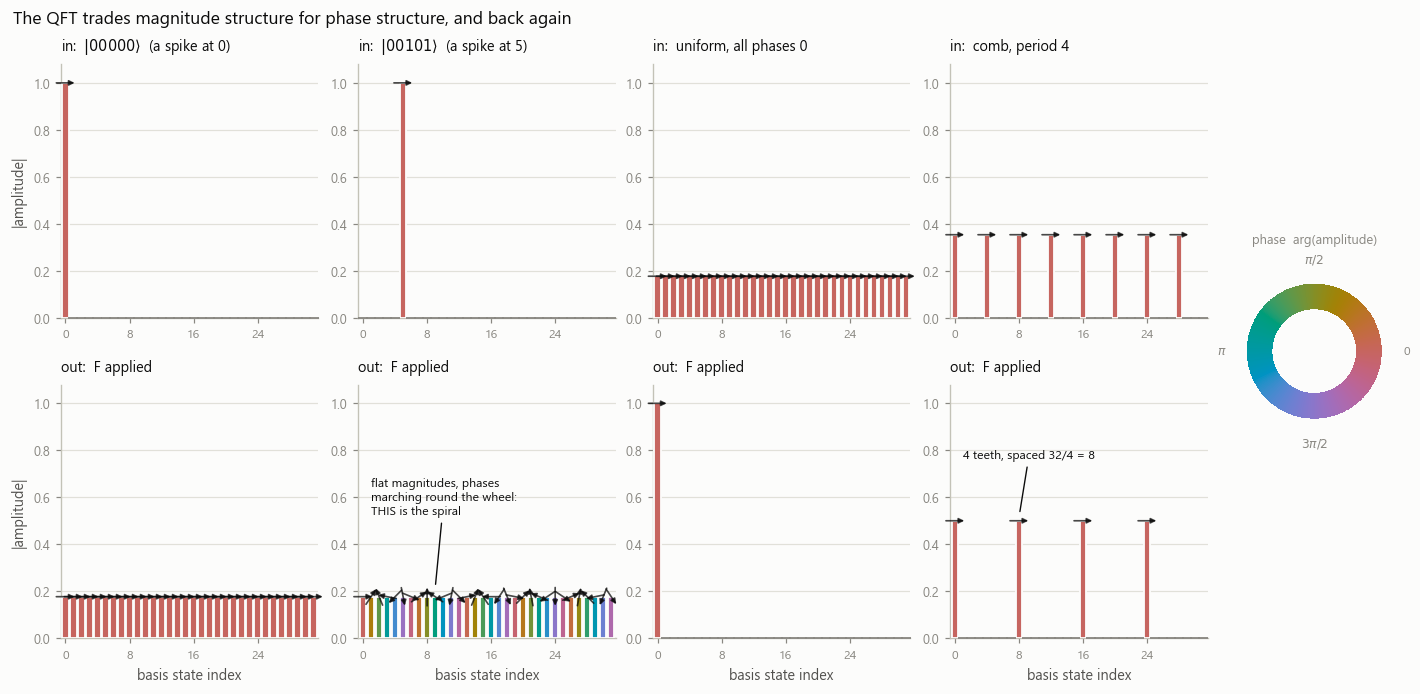

|5> transformed: phase advance per step = 0.3125 pi   (expected 2*5/32 pi = 0.3125 pi)
all magnitudes flat? True

comb period 4 -> non-zero output indices: [0, 8, 16, 24]   spacing 32//4 = 8


In [4]:
NQ = 5
NN = 2 ** NQ
F = qft_matrix(NQ)


def basis(idx, n_qubits=NQ):
    v = np.zeros(2 ** n_qubits, dtype=complex)
    v[idx] = 1.0
    return v


def comb(period, n_qubits=NQ):
    """Uniform amplitude on every index that is a multiple of `period`."""
    v = np.zeros(2 ** n_qubits, dtype=complex)
    v[::period] = 1.0
    return v / np.linalg.norm(v)


def bars(ax, vec, ylim=None, tick_every=8):
    """amp_bars, with the 32 ket labels thinned down to readable integers."""
    grid.amp_bars(ax, vec, ylim=ylim)
    ticks = np.arange(0, len(vec), tick_every)
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks], fontsize=8, rotation=0)
    return ax


inputs = [
    (grid.ket("00000") + "  (a spike at 0)", basis(0)),
    (grid.ket("00101") + "  (a spike at 5)", basis(5)),
    ("uniform, all phases 0", np.full(NN, 1 / np.sqrt(NN), dtype=complex)),
    ("comb, period 4", comb(4)),
]

fig = plt.figure(figsize=(12.8, 6.2))
gs = fig.add_gridspec(2, 5, width_ratios=[1, 1, 1, 1, 0.55])
outs = []
for c, (name, vec) in enumerate(inputs):
    axi = fig.add_subplot(gs[0, c])
    bars(axi, vec, ylim=1.08)
    axi.set_title("in:  " + name, loc="left", fontsize=9.5)

    axo = fig.add_subplot(gs[1, c])
    bars(axo, F @ vec, ylim=1.08)
    axo.set_title("out:  F applied", loc="left", fontsize=9.5)
    axo.set_xlabel("basis state index")
    if c:
        axi.set_ylabel("")
        axo.set_ylabel("")
    outs.append(axo)

grid.annotate(outs[1], "flat magnitudes, phases\nmarching round the wheel:\n"
              "THIS is the spiral", xy=(9.0, 0.21), xytext=(1.0, 0.60),
              color=style.INK, size=8)
grid.annotate(outs[3], "4 teeth, spaced 32/4 = 8", xy=(8.0, 0.52),
              xytext=(1.0, 0.78), color=style.INK, size=8)

axw = fig.add_subplot(gs[:, 4], projection="polar")
style.phase_wheel(axw)
fig.suptitle("The QFT trades magnitude structure for phase structure, "
             "and back again", x=0.005, ha="left", fontsize=11.5)
plt.show()

out5 = F @ basis(5)
step = np.angle(out5[1] / out5[0]) % (2 * np.pi)
print(f"|5> transformed: phase advance per step = {step/np.pi:.4f} pi"
      f"   (expected 2*5/32 pi = {2*5/32:.4f} pi)")
print("all magnitudes flat?", np.allclose(np.abs(out5), 1 / np.sqrt(NN)))

out_comb = F @ comb(4)
peaks = np.flatnonzero(np.abs(out_comb) > 1e-9)
print("\ncomb period 4 -> non-zero output indices:", peaks.tolist(),
      f"  spacing {NN}//4 = {NN//4}")

## Figure 3 — period in, frequency out, and the first sight of leakage

Push the comb harder. For a period $r$ that **divides** $N$, the comb has $N/r$
teeth going in and $r$ teeth coming out, spaced $N/r$ apart, each with amplitude
$1/\sqrt r$. Perfectly clean, every time.

For a period that **does not divide** $N$ — the fourth panel, $r = 5$ into
$N = 32$ — the output cannot be clean, because there is no integer $k$ with
$k \cdot 5 = 32$. The transform does the best it can: it puts most of the weight
near the five would-be positions $32m/5 = 0, 6.4, 12.8, 19.2, 25.6$ and spreads
the rest into their neighbours.

That smear is **spectral leakage**, and it is the honest cost of a finite
register. Keep the shape in your eye; the phase-estimation figures below are the
same picture with different labels.

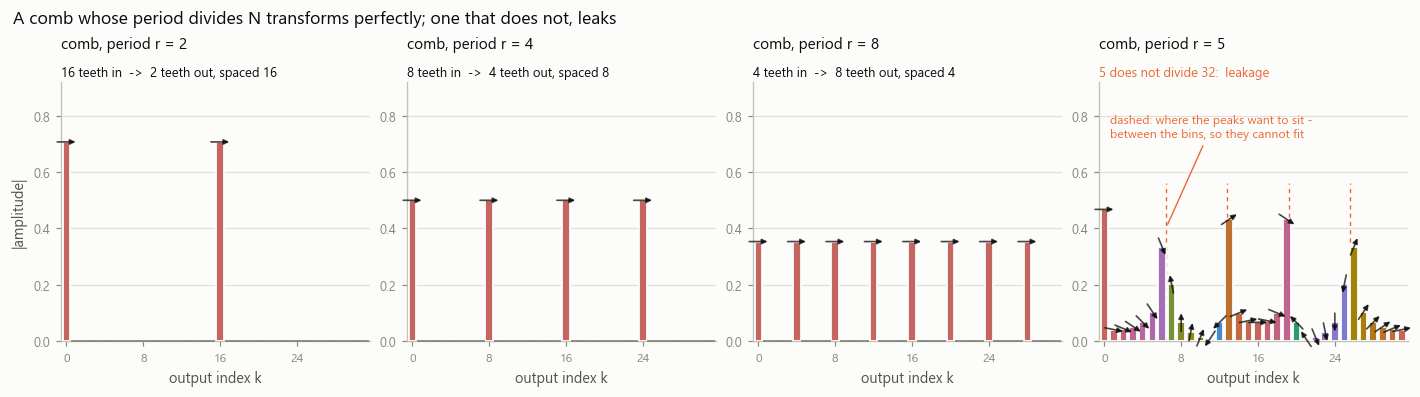

period  2:  2 non-zero output bins, largest bin holds 0.5000 of the probability
period  4:  4 non-zero output bins, largest bin holds 0.2500 of the probability
period  8:  8 non-zero output bins, largest bin holds 0.1250 of the probability
period  5: 32 non-zero output bins, largest bin holds 0.2187 of the probability


In [5]:
periods = [2, 4, 8, 5]

fig, axes = plt.subplots(1, 4, figsize=(12.8, 3.5))
for ax, r in zip(axes, periods):
    out = F @ comb(r)
    bars(ax, out, ylim=0.92)
    divides = NN % r == 0
    if divides:
        sub = f"{NN//r} teeth in  ->  {r} teeth out, spaced {NN//r}"
        col = style.INK
    else:
        sub = f"{r} does not divide {NN}:  leakage"
        col = style.ORANGE
    ax.set_title(f"comb, period r = {r}", loc="left", fontsize=10, pad=22)
    ax.text(0.0, 1.012, sub, transform=ax.transAxes, fontsize=8.5, color=col,
            va="bottom")
    ax.set_xlabel("output index k")
    if ax is not axes[0]:
        ax.set_ylabel("")

    if not divides:
        for m in range(1, r):
            ax.vlines(NN * m / r, 0, 0.56, color=style.ORANGE, lw=0.9,
                      ls=(0, (3, 3)), zorder=1)
        grid.annotate(ax, "dashed: where the peaks want to sit -\n"
                      "between the bins, so they cannot fit",
                      xy=(NN * 1 / r, 0.40), xytext=(0.6, 0.76),
                      color=style.ORANGE, size=8)

fig.suptitle("A comb whose period divides N transforms perfectly; one that does "
             "not, leaks", x=0.005, ha="left", fontsize=11.5)
plt.show()

for r in periods:
    out = np.abs(F @ comb(r)) ** 2
    big = np.flatnonzero(out > 1e-9)
    print(f"period {r:>2}: {len(big):>2} non-zero output bins, "
          f"largest bin holds {out.max():.4f} of the probability")

## Figure 4 — the circuit, and the swap layer that everyone forgets

A dense $N\times N$ matrix is not an algorithm. Here is the QFT as a *circuit*,
derived rather than quoted.

Start from the product form. Substituting $k = \sum_q k_q 2^q$ into
$F|j\rangle = N^{-1/2}\sum_k \omega^{jk}|k\rangle$ factorises the sum:

$$F\,|j\rangle \;=\; \frac{1}{\sqrt N}\bigotimes_{q=n-1}^{0}
\Big(|0\rangle + e^{2\pi i\,j/2^{\,n-q}}\,|1\rangle\Big)_q .$$

Read off what each output qubit must hold:

| output qubit | phase it must carry | depends on |
|---|---|---|
| $q = n-1$ | $2\pi j/2 = \pi j_0$ | **only** bit $j_0$ |
| $q = n-2$ | $2\pi j/4$ | bits $j_0, j_1$ |
| $\vdots$ | | |
| $q = 0$ | $2\pi j/2^n$ | every bit |

Two things fall straight out.

**First, the ladder.** Put a Hadamard on qubit $q$ — that produces
$|0\rangle + e^{i\pi j_q}|1\rangle$, the $j_q/2$ term — then add the remaining
terms with **controlled-phase** gates
$\mathrm{CP}(\theta) = \mathrm{diag}(1,1,1,e^{i\theta})$ controlled by the lower
qubits, with $\theta = 2\pi/2^{\,q-m+1}$ for control $m < q$. Total gate count:
$n$ Hadamards plus $\binom{n}{2}$ controlled-phases, so $n(n+1)/2$ gates.

Note that CP is *symmetric* in its two qubits — it is diagonal, so which one you
call the control is a naming choice, exactly as with CZ in A06.

**Second, the reversal.** Work the algebra through (we do, in code, below) and
the ladder leaves qubit $q$ holding the phase that output qubit $n-1-q$ was
supposed to have. Every qubit is in the right *state* and the wrong *place*. So
the circuit ends with $\lfloor n/2 \rfloor$ SWAPs reversing the register.

That swap layer is the single most-skipped line in QFT implementations, and
skipping it does not raise an error — it silently returns the QFT composed with a
**bit-reversal permutation**. Panel 2 below is what that looks like: the swirl
shredded into noise. If your Shor implementation returns garbage, look here
first.

In [6]:
def cphase(theta, a, b, n):
    """Controlled-phase between qubits a and b: multiply |..1..1..> by e^{i t}.

    Built as  I - P11 + e^{i theta} P11  with  P11 = |1><1|_a |1><1|_b.
    Symmetric in a and b by construction - a controlled-phase has no control.
    """
    both = op_on(P1, a, n) @ op_on(P1, b, n)
    return np.eye(2 ** n, dtype=complex) - both + np.exp(1j * theta) * both


def swap_qubits(a, b, n):
    """Permutation matrix exchanging qubits a and b of an n-qubit register."""
    dim = 2 ** n
    M = np.zeros((dim, dim), dtype=complex)
    for i in range(dim):
        ba, bb = (i >> a) & 1, (i >> b) & 1
        j = i ^ ((ba ^ bb) << a) ^ ((ba ^ bb) << b)
        M[j, i] = 1.0
    return M


def qft_circuit(n, *, swaps=True, cutoff=None):
    """The QFT as a product of H, CP and SWAP - one gate at a time.

    `cutoff` truncates the controlled-phase ladder: rotations with
    theta = 2*pi/2**k for k > cutoff are dropped (the approximate QFT).
    """
    M = np.eye(2 ** n, dtype=complex)
    for q in range(n - 1, -1, -1):              # high qubit first
        M = op_on(H, q, n) @ M
        for m in range(q - 1, -1, -1):          # controls are the lower qubits
            k = q - m + 1                       # theta = 2*pi / 2**k
            if cutoff is not None and k > cutoff:
                continue
            M = cphase(2 * np.pi / 2 ** k, m, q, n) @ M
    if swaps:
        for q in range(n // 2):
            M = swap_qubits(q, n - 1 - q, n) @ M
    return M


def bit_reversal(n):
    """Permutation sending index j to the index with its bits reversed."""
    dim = 2 ** n
    M = np.zeros((dim, dim), dtype=complex)
    for i in range(dim):
        r = int(format(i, f"0{n}b")[::-1], 2)
        M[r, i] = 1.0
    return M


print(f"{'n':>2} {'gates':>6}   circuit == matrix?   max |difference|")
for n in range(1, 8):
    Fn = qft_matrix(n)
    Cn = qft_circuit(n)
    diff = np.max(np.abs(Cn - Fn))
    print(f"{n:>2} {n*(n+1)//2:>6}   {str(np.allclose(Cn, Fn, atol=1e-12)):>17}"
          f"   {diff:.2e}")

n = 5
F5 = qft_matrix(n)
ladder = qft_circuit(n, swaps=False)
full = qft_circuit(n, swaps=True)
print("\nladder without the swap layer == (bit reversal) @ F ?",
      np.allclose(ladder, bit_reversal(n) @ F5, atol=1e-12))

 n  gates   circuit == matrix?   max |difference|
 1      1                True   8.66e-17
 2      3                True   2.69e-16
 3      6                True   1.43e-15
 4     10                True   2.29e-15
 5     15                True   3.49e-15
 6     21                True   5.10e-15


 7     28                True   7.24e-15

ladder without the swap layer == (bit reversal) @ F ? True


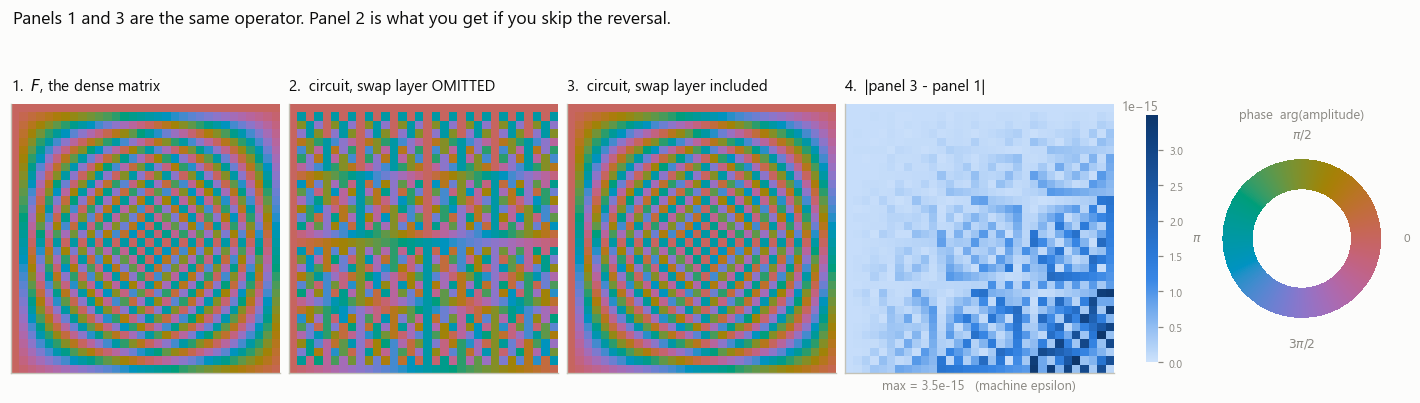

hamming: how many of the 1024 entries does the missing swap layer move? 736 of 1024


In [7]:
fig = plt.figure(figsize=(12.8, 4.0))
gs = fig.add_gridspec(1, 5, width_ratios=[1, 1, 1, 1, 0.62])

panels = [
    (r"1.  $F$, the dense matrix", F5),
    ("2.  circuit, swap layer OMITTED", ladder),
    ("3.  circuit, swap layer included", full),
]
for c, (name, M) in enumerate(panels):
    ax = fig.add_subplot(gs[0, c])
    grid.matrix(ax, M, part="phase", cbar=False, annot=False, title=name)

axd = fig.add_subplot(gs[0, 3])
resid = np.abs(full - F5)
im = axd.imshow(resid, cmap=style.SEQ, vmin=0, vmax=max(resid.max(), 1e-18),
                interpolation="nearest")
axd.set_xticks([])
axd.set_yticks([])
axd.grid(False)
axd.set_title("4.  |panel 3 - panel 1|", loc="left", fontsize=10)
cb = axd.figure.colorbar(im, ax=axd, fraction=0.046, pad=0.03)
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=7, color=style.MUTED, labelcolor=style.MUTED)
axd.set_xlabel(f"max = {resid.max():.1e}   (machine epsilon)", fontsize=8.5,
               color=style.MUTED)

axw = fig.add_subplot(gs[0, 4], projection="polar")
style.phase_wheel(axw)
fig.suptitle("Panels 1 and 3 are the same operator. Panel 2 is what you get "
             "if you skip the reversal.", x=0.005, ha="left", fontsize=11.5)
plt.show()

print("hamming: how many of the 1024 entries does the missing swap layer move?",
      int(np.sum(~np.isclose(ladder, F5, atol=1e-12))), "of", F5.size)

Panel 2 is worth staring at. It is not *wrong* in the sense of being non-unitary
— it is a perfectly good unitary, and it agrees with $F$ on magnitudes
everywhere, since every entry of both matrices has magnitude $1/\sqrt N$. The
only thing that changed is *which row each phase ramp landed on*, and that
destroys the swirl completely.

There is a defensible engineering choice hiding here: since the swaps are pure
relabelling, a compiler can often **delete the swap layer and renumber the wires
instead**, which is free. Qiskit's `QFTGate` has a `do_swaps` flag for exactly
this reason, and B23 puts the two side by side. What you must not do is delete
the layer and *forget* you did.

## Phase estimation: the setup

Now the payoff. We are given a unitary $U$ and an eigenstate $|u\rangle$ with

$$U\,|u\rangle = e^{2\pi i \varphi}\,|u\rangle, \qquad \varphi \in [0, 1),$$

and we want $\varphi$. Eigenvalues of a unitary have modulus 1, so the *only*
thing there is to learn is the phase — and phase is invisible to measurement
until you interfere it with something. Phase estimation is the machine that does
the interfering.

**The register layout, stated explicitly.** We use $t$ **counting** qubits,
numbered $0 \ldots t-1$, plus a target register holding $|u\rangle$. Little-endian
means the counting register's value is the *low* $t$ bits of the full index, and
the target sits at qubit $t$ — the leftmost character. So an operator acting only
on the counting register is embedded as $I_2 \otimes M$, target first.

**The circuit.**

1. Hadamard every counting qubit: $\;N^{-1/2}\sum_{j=0}^{N-1}|j\rangle$, $N = 2^t$.
2. For each $k$, apply **controlled-$U^{2^k}$** with counting qubit $k$ as
   control. Because $|u\rangle$ is an eigenstate, $U^{2^k}$ does nothing to the
   target and instead **kicks back** a phase $e^{2\pi i \varphi 2^k}$ onto the
   control — the mechanism A06's deep dive and A08 built. After the whole layer
   the counting register holds

   $$\frac{1}{\sqrt N}\sum_{j=0}^{N-1} e^{2\pi i \varphi j}\,|j\rangle,$$

   because $\sum_k j_k 2^k = j$. **That is the spiral**, winding at rate
   $\varphi$.
3. Apply $F^\dagger$ to the counting register.
4. Measure.

For concreteness we take $U = \mathrm{diag}(1, e^{2\pi i \varphi})$ on a single
target qubit with $|u\rangle = |1\rangle$, so that controlled-$U^{2^k}$ is
*exactly* the same `cphase` gate we already built, with $\theta = 2\pi\varphi
2^k$. That keeps the notebook about phase estimation rather than about circuit
synthesis — and it is a real, honest instance of the algorithm, not a
simulation of one.

**The analytic answer.** Step 3 gives amplitude

$$c_m = \frac{1}{N}\sum_{j=0}^{N-1} e^{2\pi i(\varphi - m/N)\,j}
\quad\Longrightarrow\quad
P(m) = \frac{1}{N^2}\,\frac{\sin^2\!\big(\pi N\delta_m\big)}{\sin^2\!\big(\pi \delta_m\big)},
\qquad \delta_m = \varphi - \frac{m}{N}.$$

That is the **Dirichlet kernel** — the discrete sinc. If $\varphi N$ is an
integer the sum is a perfect geometric series that collapses to a single term:
one outcome, probability exactly 1. Otherwise you get the sinc-like skirt. We
will plot the formula on top of the simulated bars and check they agree to
$10^{-12}$.

In [8]:
def qpe_probs(phi, t):
    """Run phase estimation from scratch. Returns P(m) over the counting register.

    Counting qubits are 0..t-1 (the low bits); the target eigenstate qubit is
    qubit t (the leftmost label character). Everything is an explicit matrix
    acting on an explicit statevector - no shortcuts.
    """
    n = t + 1
    N = 2 ** t

    # |u> = |1> on the target, |0...0> on the counting register.
    psi = np.zeros(2 ** n, dtype=complex)
    psi[1 << t] = 1.0

    # 1. Hadamard the counting register.
    for q in range(t):
        psi = op_on(H, q, n) @ psi

    # 2. Controlled-U^(2^k). With U = diag(1, e^{2 pi i phi}) and |u> = |1>,
    #    controlled-U^(2^k) IS a controlled-phase of angle 2 pi phi 2^k.
    for k in range(t):
        psi = cphase(2 * np.pi * phi * 2 ** k, k, t, n) @ psi

    # 3. Inverse QFT on the counting register. Target is the highest qubit, so
    #    it is the FIRST Kronecker factor: I (x) F^dagger.
    psi = np.kron(I2, qft_matrix(t).conj().T) @ psi

    # 4. Marginal over the target. index = target_bit * N + m.
    return (np.abs(psi.reshape(2, N)) ** 2).sum(axis=0)


def dirichlet(phi, t):
    """P(m) = sin^2(pi N d) / (N^2 sin^2(pi d)),  d = phi - m/N.  Analytic."""
    N = 2 ** t
    d = phi - np.arange(N) / N
    num = np.sin(np.pi * N * d) ** 2
    den = (N * np.sin(np.pi * d)) ** 2
    out = np.where(np.abs(den) < 1e-24, 1.0, num / np.where(den == 0, 1, den))
    return out


T = 5
NT = 2 ** T

cases = [
    ("exact:  " + r"$\varphi = 5/32$", 5 / 32),
    ("inexact:  " + r"$\varphi = 0.3$", 0.3),
    ("worst case:  " + r"$\varphi = 9.5/32$", 9.5 / 32),
]
for name, phi in cases:
    p = qpe_probs(phi, T)
    a = dirichlet(phi, T)
    m = int(np.argmax(p))
    print(f"phi = {phi:.6f}   phi*N = {phi*NT:7.3f}   best m = {m:>2} "
          f"({label(m, T)})   P = {p[m]:.6f}   sum = {p.sum():.10f}   "
          f"matches analytic: {np.allclose(p, a, atol=1e-12)}")

phi = 0.156250   phi*N =   5.000   best m =  5 (00101)   P = 1.000000   sum = 1.0000000000   matches analytic: True
phi = 0.300000   phi*N =   9.600   best m = 10 (01010)   P = 0.573081   sum = 1.0000000000   matches analytic: True
phi = 0.296875   phi*N =   9.500   best m =  9 (01001)   P = 0.405610   sum = 1.0000000000   matches analytic: True


## Figure 5 — one sharp peak, and two that leak

Three runs at $t = 5$ counting qubits, $N = 32$.

**Left: $\varphi = 5/32$.** Exactly representable in 5 bits. The measurement
returns $m = 5$, bitstring `00101`, with probability **1** — not 0.999, exactly
1, to machine precision. Every other amplitude cancels dead. This is the case the
textbooks draw, and it is the least representative one.

**Middle: $\varphi = 0.3$.** In binary $0.3 = 0.0100110011\overline{0011}\ldots$,
so it is never exactly representable in any finite number of bits. $\varphi N =
9.6$, which is not an integer, so the spiral does not fit a whole number of turns
into the register and the peak spills. The nearest bitstring $m = 10$ still wins
comfortably, but around a third of the probability has leaked into its
neighbours — and note the skirt is *asymmetric*, leaning toward 9, because 9.6 is
closer to 10 than to 9.

**Right: $\varphi = 9.5/32$.** The worst possible case: $\varphi N = 9.5$ sits
exactly halfway between two integers, so 9 and 10 are equally good and equally
bad. This is where the famous bound bites. The dashed line is $4/\pi^2 \approx
0.4053$, and the theorem is that **the nearest integer to $\varphi N$ is returned
with probability at least $4/\pi^2$, whatever $\varphi$ is**. At finite $N$ the
true worst case is $1/(N^2\sin^2(\pi/2N))$, marginally *above* $4/\pi^2$ and
decreasing to it as $N \to \infty$ — so the bound is a floor that is approached
but never crossed.

The orange curve is the Dirichlet kernel evaluated at the same points and it lies
on the bars to $10^{-12}$: the simulation and the algebra are the same object.

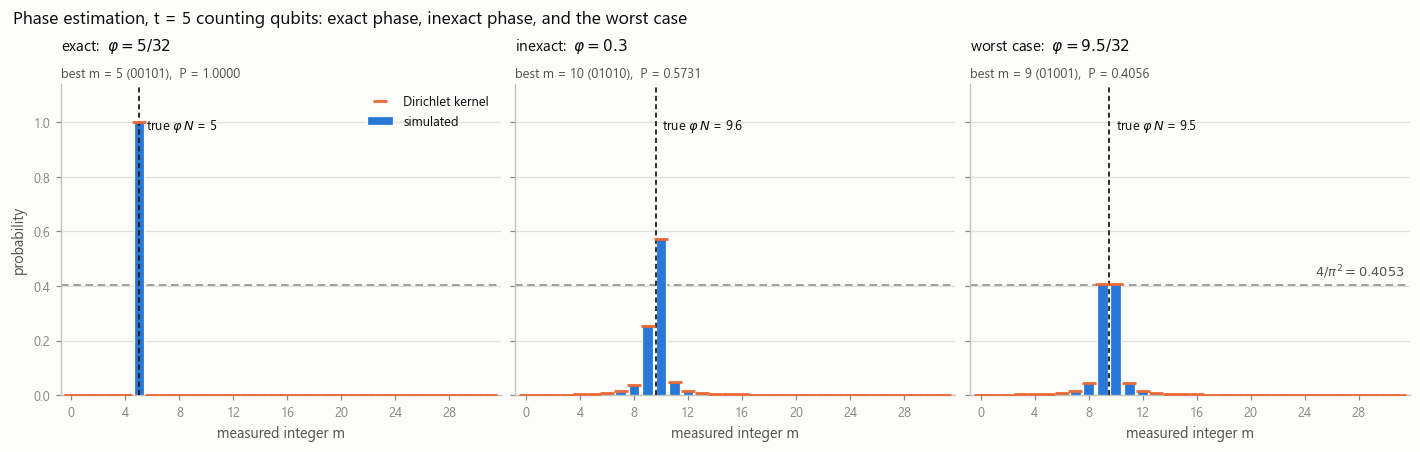

phi*N =   5.00:  P(best) = 1.0000   P(best two) = 1.0000   leaked elsewhere = 0.0000
phi*N =   9.60:  P(best) = 0.5731   P(best two) = 0.8279   leaked elsewhere = 0.1721
phi*N =   9.50:  P(best) = 0.4056   P(best two) = 0.8112   leaked elsewhere = 0.1888

4/pi^2 = 0.405285
true finite-N worst case at N=32: 0.405610  (above the bound, as promised)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12.8, 4.0), sharey=True)
BOUND = 4 / np.pi ** 2

for ax, (name, phi) in zip(axes, cases):
    p = qpe_probs(phi, T)
    m = int(np.argmax(p))
    idx = np.arange(NT)

    ax.bar(idx, p, width=0.8, color=style.BLUE, edgecolor=style.SURFACE,
           linewidth=0.8, zorder=3, label="simulated")
    ax.plot(idx, dirichlet(phi, T), ls="none", marker="_", ms=9, mew=1.8,
            color=style.ORANGE, zorder=5, label="Dirichlet kernel")
    ax.axvline(phi * NT, color=style.INK, lw=1.1, ls=(0, (3, 2)), zorder=4)
    ax.text(phi * NT + 0.5, 1.02, r"true $\varphi\,N$ = " + f"{phi*NT:g}",
            fontsize=8.5, color=style.INK, va="top")

    ax.axhline(BOUND, color=style.MUTED, lw=1.0, ls=(0, (5, 3)), zorder=2)
    ax.set_xlim(-0.8, NT - 0.2)
    ax.set_ylim(0, 1.14)
    ax.set_xticks(np.arange(0, NT, 4))
    ax.set_xlabel("measured integer m")
    ax.set_title(name, loc="left", fontsize=10, pad=22)
    ax.text(0.0, 1.012, f"best m = {m} ({label(m, T)}),  P = {p[m]:.4f}",
            transform=ax.transAxes, fontsize=8.5, color=style.INK_2,
            va="bottom")

axes[0].set_ylabel("probability")
axes[0].legend(loc="upper right", markerscale=1.0)
axes[2].text(NT - 0.6, BOUND + 0.03, r"$4/\pi^2 = 0.4053$", ha="right",
             fontsize=8.5, color=style.INK_2)
fig.suptitle("Phase estimation, t = 5 counting qubits: exact phase, inexact "
             "phase, and the worst case", x=0.005, ha="left", fontsize=11.5)
plt.show()

for name, phi in cases:
    p = qpe_probs(phi, T)
    order = np.argsort(-p)
    top2 = float(p[order[0]] + p[order[1]])
    print(f"phi*N = {phi*NT:6.2f}:  P(best) = {p[order[0]]:.4f}   "
          f"P(best two) = {top2:.4f}   "
          f"leaked elsewhere = {1-top2:.4f}")
print(f"\n4/pi^2 = {BOUND:.6f}")
print(f"true finite-N worst case at N=32: "
      f"{1/(NT**2 * np.sin(np.pi/(2*NT))**2):.6f}  (above the bound, as promised)")

## Figure 6 — more counting qubits, sharper peak

Each extra counting qubit doubles $N$, which halves the bin width $1/N$ and so
buys **one more bit of $\varphi$**. The small multiples below all show the same
$\varphi = 0.3$, plotted against $m/N$ rather than $m$ so the horizontal axis
means the same thing in every panel: the peak stays put at $0.3$ and gets
narrower.

Two separate things are worth tracking, and they behave differently:

- **Resolution** improves geometrically. The peak's width in units of $\varphi$
  is $\sim 1/N = 2^{-t}$.
- **Peak height does not improve at all.** The right-hand panel plots
  $P(\text{best } m)$ against $t$ and it wanders around in a band above
  $4/\pi^2$ forever, depending on how nearly $\varphi 2^t$ lands on an integer at
  that particular $t$. Adding qubits makes the answer *more precise*, never *more
  certain*.

That second point is the practical one. If you need success probability $1 -
\epsilon$ rather than $0.4$, you do not add counting qubits — you add
$O(\log 1/\epsilon)$ **extra** qubits (which buys precision you then throw away)
or, more cheaply, you repeat the whole experiment and take a majority vote.
Repetition is the standard fix, and it is why the honest cost of phase estimation
is measured in *runs*, not just in qubits.

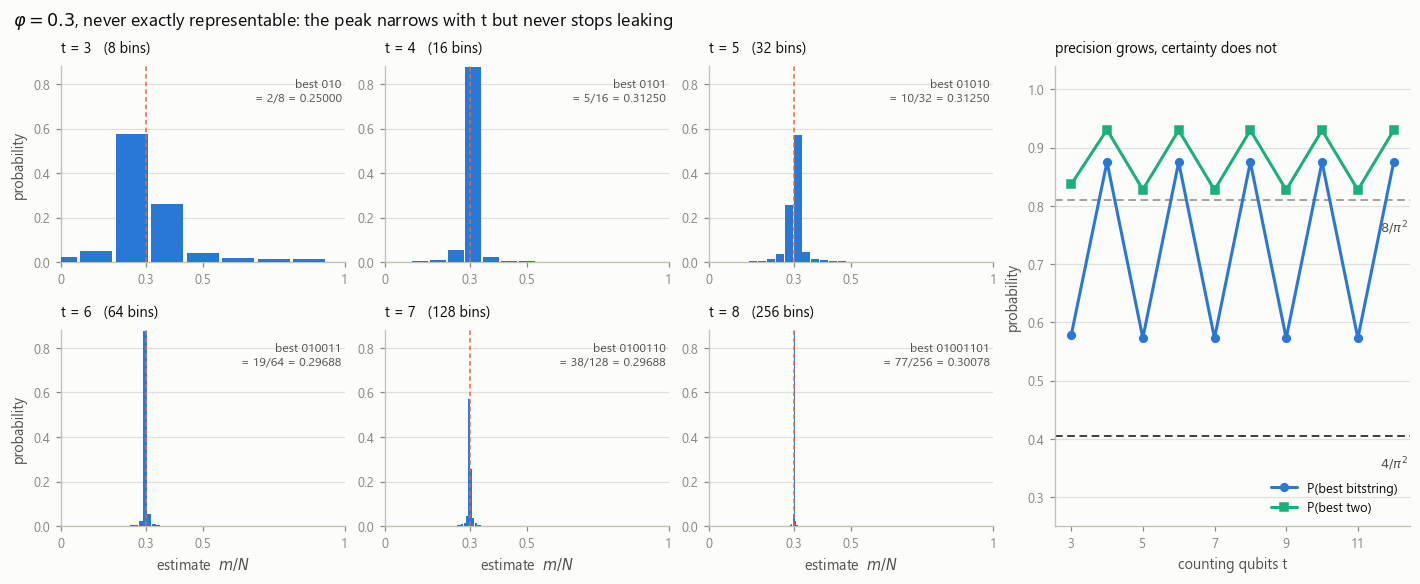

  t   bin width    best m/N    |error|   P(best)
  3    0.125000    0.250000   0.050000    0.5775
  4    0.062500    0.312500   0.012500    0.8756
  5    0.031250    0.312500   0.012500    0.5731
  6    0.015625    0.296875   0.003125    0.8752
  7    0.007812    0.296875   0.003125    0.5728


  8    0.003906    0.300781   0.000781    0.8751


In [10]:
PHI = 0.3
ts = [3, 4, 5, 6, 7, 8]

fig = plt.figure(figsize=(12.8, 5.2))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 1.25])

for i, t in enumerate(ts):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    N = 2 ** t
    p = qpe_probs(PHI, t)
    m = int(np.argmax(p))
    ax.bar(np.arange(N) / N, p, width=0.9 / N, color=style.BLUE, zorder=3)
    ax.axvline(PHI, color=style.ORANGE, lw=1.0, ls=(0, (3, 2)), zorder=4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 0.88)
    ax.set_xticks([0, 0.3, 0.5, 1.0])
    ax.set_xticklabels(["0", "0.3", "0.5", "1"])
    ax.set_title(f"t = {t}   ({N} bins)", loc="left", fontsize=9.5)
    ax.text(0.99, 0.94, f"best {label(m, t)}\n= {m}/{N} = {m/N:.5f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            color=style.INK_2)
    if i % 3:
        ax.set_ylabel("")
    else:
        ax.set_ylabel("probability")
    if i // 3:
        ax.set_xlabel(r"estimate  $m/N$")

axs = fig.add_subplot(gs[:, 3])
tt = np.arange(3, 13)
best = []
top2 = []
for t in tt:
    N = 2 ** t
    a = dirichlet(PHI, t)
    o = np.argsort(-a)
    best.append(a[o[0]])
    top2.append(a[o[0]] + a[o[1]])
axs.plot(tt, best, marker="o", color=style.BLUE, label="P(best bitstring)")
axs.plot(tt, top2, marker="s", color=style.AQUA, label="P(best two)")
axs.axhline(4 / np.pi ** 2, color=style.INK, lw=1.0, ls=(0, (5, 3)), zorder=1)
axs.axhline(8 / np.pi ** 2, color=style.MUTED, lw=1.0, ls=(0, (5, 3)), zorder=1)
axs.text(12.4, 4 / np.pi ** 2 - 0.055, r"$4/\pi^2$", ha="right", fontsize=8.5,
         color=style.INK_2)
axs.text(12.4, 8 / np.pi ** 2 - 0.055, r"$8/\pi^2$", ha="right", fontsize=8.5,
         color=style.INK_2)
axs.set_xlabel("counting qubits t")
axs.set_ylabel("probability")
axs.set_ylim(0.25, 1.04)
axs.set_xticks(tt[::2])
axs.legend(loc="lower right")
axs.set_title("precision grows, certainty does not", loc="left", fontsize=9.5)

fig.suptitle(r"$\varphi = 0.3$, never exactly representable: the peak narrows "
             "with t but never stops leaking", x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"{'t':>3} {'bin width':>11} {'best m/N':>11} {'|error|':>10} {'P(best)':>9}")
for t in ts:
    N = 2 ** t
    p = qpe_probs(PHI, t)
    m = int(np.argmax(p))
    print(f"{t:>3} {1/N:>11.6f} {m/N:>11.6f} {abs(m/N - PHI):>10.6f} "
          f"{p[m]:>9.4f}")

## Figure 7 — the rotations get exponentially small, so hardware throws them away

One more piece of honesty about the circuit. The controlled-phase ladder uses
angles $2\pi/2^k$ for $k$ up to $n$. At $n = 20$ the smallest rotation is
$2\pi/2^{20} \approx 6 \times 10^{-6}$ radians — far below the calibration
precision of any real gate, and utterly swamped by noise. Implementing it costs a
full two-qubit gate's worth of error to apply an operation indistinguishable from
the identity.

So real implementations use the **approximate QFT (AQFT)**: drop every rotation
with $k > \text{cutoff}$. The gate count falls from $O(n^2)$ to
$O(n \log n)$ for a cutoff of $O(\log n)$, and — the striking part — the error
falls off *exponentially* in the cutoff. Below, the operator error is
$\max_{jk}|F^{\text{AQFT}}_{jk} - F_{jk}|$ for $n = 8$.

Coppersmith's original analysis gives an error bound of order $n^2 2^{-\text{cutoff}}$,
and on a noisy device the AQFT is often *more* accurate than the exact QFT,
because the gates you removed were contributing more noise than signal. That is a
genuinely counter-intuitive engineering result and it is the norm, not an
exception.

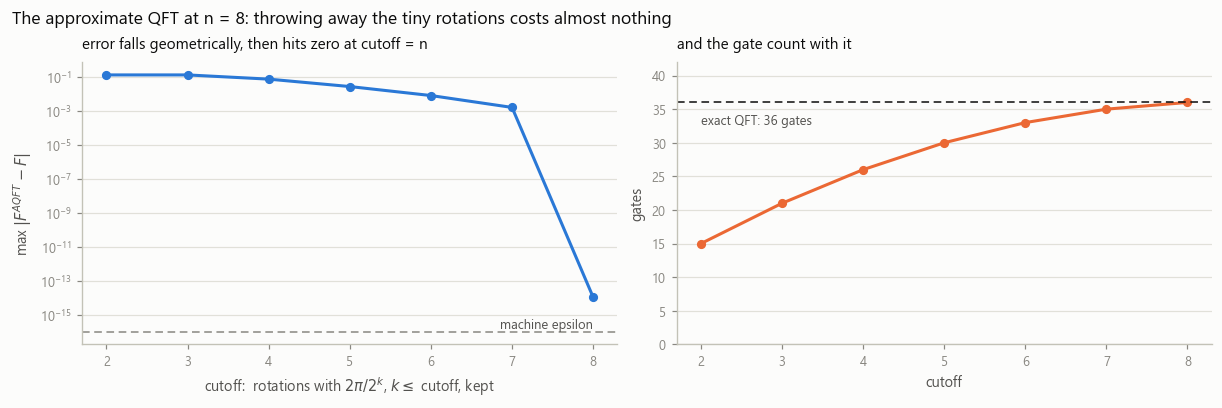

 cutoff  gates    max error
      2     15    1.250e-01
      3     21    1.250e-01
      4     26    7.072e-02
      5     30    2.589e-02
      6     33    7.665e-03
      7     35    1.534e-03
      8     36    1.065e-14


In [11]:
NA = 8
FA = qft_matrix(NA)
cutoffs = list(range(2, NA + 1))
errs, gates = [], []
for c in cutoffs:
    A = qft_circuit(NA, cutoff=c)
    errs.append(np.max(np.abs(A - FA)))
    gates.append(NA + sum(1 for q in range(NA) for m in range(q)
                          if q - m + 1 <= c))

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.6))

axes[0].semilogy(cutoffs, np.maximum(errs, 1e-17), marker="o",
                 color=style.BLUE)
axes[0].axhline(1e-16, color=style.MUTED, lw=1.0, ls=(0, (5, 3)))
axes[0].text(cutoffs[-1], 1.6e-16, "machine epsilon", ha="right", fontsize=8.5,
             color=style.INK_2)
axes[0].set_xlabel("cutoff:  rotations with " + r"$2\pi/2^k$, $k \leq$ cutoff, kept")
axes[0].set_ylabel(r"max $|F^{AQFT} - F|$")
axes[0].set_title("error falls geometrically, then hits zero at cutoff = n",
                  loc="left", fontsize=10)
axes[0].set_xticks(cutoffs)

axes[1].plot(cutoffs, gates, marker="o", color=style.ORANGE)
axes[1].axhline(NA * (NA + 1) / 2, color=style.INK, lw=1.0, ls=(0, (5, 3)))
axes[1].text(cutoffs[0], NA * (NA + 1) / 2 - 3.2,
             f"exact QFT: {NA*(NA+1)//2} gates", ha="left", fontsize=8.5,
             color=style.INK_2)
axes[1].set_xlabel("cutoff")
axes[1].set_ylabel("gates")
axes[1].set_ylim(0, NA * (NA + 1) / 2 + 6)
axes[1].set_title("and the gate count with it", loc="left", fontsize=10)
axes[1].set_xticks(cutoffs)

fig.suptitle(f"The approximate QFT at n = {NA}: throwing away the tiny "
             "rotations costs almost nothing", x=0.005, ha="left", fontsize=11.5)
plt.show()

print(f"{'cutoff':>7} {'gates':>6} {'max error':>12}")
for c, g, e in zip(cutoffs, gates, errs):
    print(f"{c:>7} {g:>6} {e:>12.3e}")

## Deep dive — reading the bits back out, and the eigenstate you don't have

*Skip on a first read.*

**Reading the register.** The measured integer $m$ is a $t$-bit little-endian
value: counting qubit $q$ carries bit $(m \gg q)\,\&\,1$, and the estimate is
$\tilde\varphi = m/2^t$. Printing `format(m, "0{t}b")` puts qubit $t-1$ on the
left, which is the ordering the binary fraction $0.j_{t-1}j_{t-2}\ldots j_0$
wants — so the printed string reads directly as the binary expansion of
$\tilde\varphi$. Verified below.

**Superpositions of eigenstates.** Nothing in the derivation required $|u\rangle$
to be a single eigenstate. If the target starts in $\sum_u c_u |u\rangle$, then
by linearity the counting register ends up entangled with the target in
$\sum_u c_u\,|\widetilde{\varphi_u}\rangle\,|u\rangle$, and measuring the counting
register **collapses onto one eigenvalue, chosen with probability
$|c_u|^2$**. This is what makes phase estimation usable in practice: you never
need the eigenstate, only a state with decent overlap on the one you want. It is
also exactly how Shor's order-finding works — the state $|1\rangle$ is an equal
superposition of all $r$ eigenstates of the multiply-by-$a$ operator, and you get
a random one of $r$ answers per run.

We demonstrate that with a two-eigenstate target below.

In [12]:
# Reading a measured integer back as a binary fraction.
t = 6
phi_exact = 0b101101 / 2 ** t          # exactly representable in 6 bits
p = qpe_probs(phi_exact, t)
m = int(np.argmax(p))
bits = label(m, t)
recon = sum(int(b) * 2.0 ** -(i + 1) for i, b in enumerate(bits))
print(f"phi        = {phi_exact:.10f}")
print(f"measured m = {m}  bits = {bits}  with probability {p[m]:.12f}")
print(f"0.{bits} read as a binary fraction = {recon:.10f}")
print("counting qubit q holds bit (m >> q) & 1:",
      [(m >> q) & 1 for q in range(t)], " (qubit 0 first)")

# Superposition of eigenstates: target = a|0> + b|1>, eigenvalues 1 and e^{2 pi i phi}.
def qpe_superposition(phi, t, c0, c1):
    """Same circuit, but the target starts in c0|0> + c1|1>.

    |0> is an eigenstate with phase 0, |1> with phase phi. Returns the counting
    register's marginal distribution.
    """
    n = t + 1
    N = 2 ** t
    psi = np.zeros(2 ** n, dtype=complex)
    psi[0] = c0                 # target |0>, counting |0..0>
    psi[1 << t] = c1            # target |1>, counting |0..0>
    for q in range(t):
        psi = op_on(H, q, n) @ psi
    for k in range(t):
        psi = cphase(2 * np.pi * phi * 2 ** k, k, t, n) @ psi
    psi = np.kron(I2, qft_matrix(t).conj().T) @ psi
    return (np.abs(psi.reshape(2, N)) ** 2).sum(axis=0)


t = 5
c0, c1 = np.sqrt(0.25), np.sqrt(0.75)
ps = qpe_superposition(6 / 32, t, c0, c1)
print(f"\ntarget = sqrt(0.25)|0> + sqrt(0.75)|1>,  phases 0 and 6/32")
print("counting register outcome probabilities (non-zero only):")
for m in np.flatnonzero(ps > 1e-12):
    print(f"  m = {m:>2} ({label(m, t)}) -> phi_est = {m/2**t:.5f}"
          f"   P = {ps[m]:.4f}")
print("i.e. you learn ONE eigenvalue per run, with probability |c_u|^2.")

phi        = 0.7031250000
measured m = 45  bits = 101101  with probability 1.000000000000
0.101101 read as a binary fraction = 0.7031250000
counting qubit q holds bit (m >> q) & 1: [1, 0, 1, 1, 0, 1]  (qubit 0 first)

target = sqrt(0.25)|0> + sqrt(0.75)|1>,  phases 0 and 6/32
counting register outcome probabilities (non-zero only):
  m =  0 (00000) -> phi_est = 0.00000   P = 0.2500
  m =  6 (00110) -> phi_est = 0.18750   P = 0.7500
i.e. you learn ONE eigenvalue per run, with probability |c_u|^2.


## What this picture hides

**The QFT is not a fast DFT for classical data — this is the single most common
misreading of the whole subject.** Two walls, either of which is fatal on its
own:

- *Loading.* To Fourier-transform your $N$-point signal you must first get those
  $N$ amplitudes into the register. In general that is $O(N)$ work, which already
  costs more than the classical FFT you were trying to beat.
- *Reading.* After the transform the answer is a superposition of $N$ amplitudes,
  and a measurement returns **one index**, sampled from $|c_k|^2$. You cannot
  read out the spectrum; you cannot even read out one amplitude. Everything is in
  there and none of it is accessible.

The QFT is useful only when it sits *inside* a larger algorithm that needs a
single number — a period, a phase — and where interference has already arranged
for that number to dominate the distribution. Shor is the canonical case. "Use a
quantum computer to speed up my signal processing" is not.

**The exact-phase demo is the unrepresentative case.** Figure 5's left panel
returns the right answer with probability 1 and it is very seductive. Real phases
are irrational; the honest picture is the middle and right panels, where a third
to half the probability is in the skirt and you need repetition or continued
fractions (C26) to finish the job.

**The cost is in the controlled-$U^{2^k}$, not in the QFT.** Our $U$ was a
one-qubit phase gate, so $U^{2^k}$ was free — we just multiplied the angle. For a
real $U$ you must implement $U$ raised to the power $2^{t-1}$, and unless $U$ has
special structure that is $2^{t-1}$ applications. The QFT's $O(t^2)$ gates are a
rounding error next to that. Every headline "phase estimation is efficient" is
implicitly assuming an efficient controlled-$U^{2^k}$, and finding one is the
actual algorithm-design problem.

**You need the eigenstate, or at least overlap with it.** The deep dive showed
that a superposition works — but if your trial state has exponentially small
overlap with the eigenvector you care about, you will wait exponentially long to
see it. This is the wall that phase-estimation-based quantum chemistry runs into
and the reason C28 uses a variational method instead.

**The swirl figure hides magnitude, deliberately.** Figure 1 draws only phase.
That is honest for the QFT, where all magnitudes are $1/\sqrt N$, and would be a
lie for almost any other matrix. Do not carry the habit over.

**Everything here is noiseless.** No decoherence, no gate error, no readout
error. On hardware, a $t$-qubit phase estimation needs coherence across
$O(2^t)$ applications of $U$; that, not the algorithm, is why factoring anything
interesting remains out of reach. B24 puts numbers on it.

## Checkpoint

In [13]:
# 1. The dense QFT matrix is unitary, symmetric, and flat in magnitude.
for n in range(1, 8):
    Fn = qft_matrix(n)
    N = 2 ** n
    assert np.allclose(Fn.conj().T @ Fn, np.eye(N), atol=1e-12)
    assert np.allclose(Fn, Fn.T, atol=1e-12)
    assert np.allclose(np.abs(Fn), 1 / np.sqrt(N), atol=1e-12)

# 2. F^4 = I, and F^2 is the index-reversal permutation.
for n in range(1, 6):
    N = 2 ** n
    Fn = qft_matrix(n)
    assert np.allclose(np.linalg.matrix_power(Fn, 4), np.eye(N), atol=1e-12)
    F2n = np.linalg.matrix_power(Fn, 2)
    for j in range(N):
        assert np.isclose(np.abs(F2n[(-j) % N, j]), 1.0, atol=1e-12)

# 3. THE assertion: the circuit form equals the dense matrix to 1e-12.
for n in range(1, 8):
    assert np.allclose(qft_circuit(n), qft_matrix(n), atol=1e-12), n

# 4. ...and omitting the swap layer gives exactly QFT-after-bit-reversal.
for n in range(2, 7):
    assert np.allclose(qft_circuit(n, swaps=False),
                       bit_reversal(n) @ qft_matrix(n), atol=1e-12), n
    assert not np.allclose(qft_circuit(n, swaps=False), qft_matrix(n))

# 5. Little-endian sanity: F|0..0> is the uniform state, and F|1> has phase
#    advancing by exactly 2*pi/N per index.
n = 4
N = 2 ** n
Fn = qft_matrix(n)
e0 = np.zeros(N, dtype=complex); e0[0] = 1
assert np.allclose(Fn @ e0, np.full(N, 1 / np.sqrt(N)))
e1 = np.zeros(N, dtype=complex); e1[1] = 1
out = Fn @ e1
assert np.allclose(np.angle(out * np.exp(-2j * np.pi * np.arange(N) / N)), 0,
                   atol=1e-12)

# 6. Period in, frequency out: a comb of period r | N gives r teeth spaced N/r.
for r in (2, 4, 8, 16):
    out = np.abs(qft_matrix(5) @ comb(r)) ** 2
    hit = np.flatnonzero(out > 1e-12)
    assert len(hit) == r
    assert np.allclose(hit, np.arange(r) * (32 // r))
    assert np.allclose(out[hit], 1 / r)

# 7. Exact-phase QPE returns the right bitstring with probability 1.
for t in (3, 4, 5, 6):
    for m_true in (0, 1, 2 ** t - 1, (2 ** t) // 3):
        p = qpe_probs(m_true / 2 ** t, t)
        assert np.isclose(p[m_true], 1.0, atol=1e-12), (t, m_true)
        assert np.isclose(p.sum(), 1.0, atol=1e-12)

# 8. The simulated distribution equals the Dirichlet kernel, always.
for t in (3, 5, 6):
    for phi in rng.uniform(0, 1, 6):
        assert np.allclose(qpe_probs(phi, t), dirichlet(phi, t), atol=1e-12)

# 9. The 4/pi^2 bound holds for every phase we can throw at it, and the finite-N
#    worst case sits just above it.
BOUND = 4 / np.pi ** 2
for t in (3, 4, 5, 6):
    N = 2 ** t
    for phi in rng.uniform(0, 1, 40):
        p = dirichlet(phi, t)
        m = int(np.round(phi * N)) % N          # nearest bitstring
        assert p[m] >= BOUND - 1e-12, (t, phi, p[m])
    worst = dirichlet((np.floor(N / 3) + 0.5) / N, t).max()
    assert worst >= BOUND
    assert np.isclose(worst, 1 / (N ** 2 * np.sin(np.pi / (2 * N)) ** 2))

# 10. The approximate QFT converges to the exact one as the cutoff grows.
prev = np.inf
for c in range(2, 10):
    e = np.max(np.abs(qft_circuit(8, cutoff=c) - qft_matrix(8)))
    assert e <= prev + 1e-15
    prev = e
assert prev < 1e-12

# 11. Every operator we built along the way is unitary.
for M in (qft_circuit(4), qft_circuit(4, swaps=False), qft_circuit(4, cutoff=3),
          swap_qubits(0, 3, 4), cphase(0.7, 1, 2, 4), bit_reversal(4)):
    assert np.allclose(M.conj().T @ M, np.eye(M.shape[0]), atol=1e-12)

# 12. Controlled-phase is symmetric in its two qubits - there is no "control".
assert np.allclose(cphase(0.9, 0, 2, 3), cphase(0.9, 2, 0, 3))

print("A11 checkpoint passed.")

A11 checkpoint passed.


---

**Next:** [A12 — Density Matrices, Mixed States, Noise Channels](A12_Density_Matrices.ipynb).
Every state in this notebook was pure, and every gate was perfect. The leakage we
measured was *structural* — it comes from the register being finite, not from
anything going wrong. A12 introduces the other kind of imperfection, the kind an
amplitude vector cannot represent at all.